# Chapter-08. 模型权重初始化的奥妙

## 【章节目标】
- 理解梯度消失和梯度爆炸的原因
- 理解通过合理初始化权重解决梯度消失和梯度爆炸的原理
- 掌握常用权重初始化方法

## 【章节内容】
### 8.1 梯度消失与爆炸
#### 1）认识nan
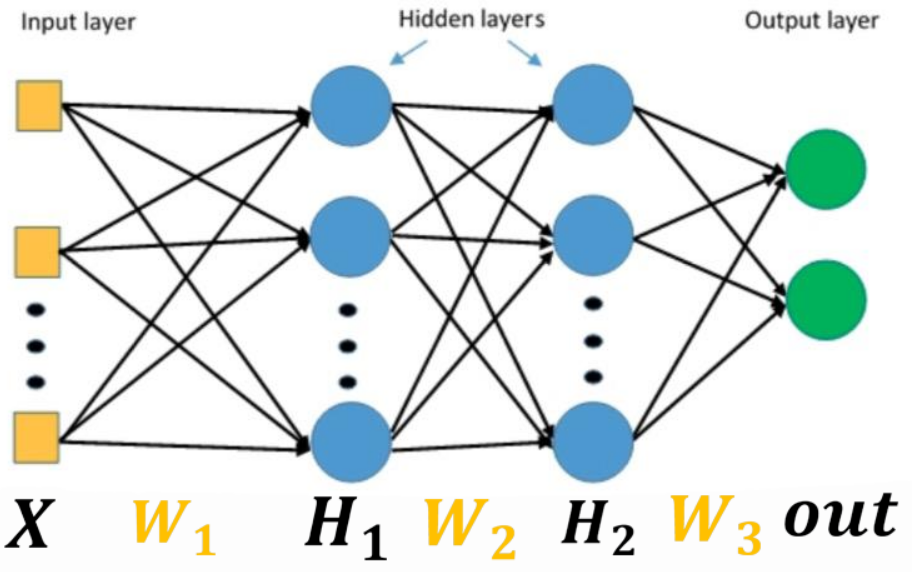  
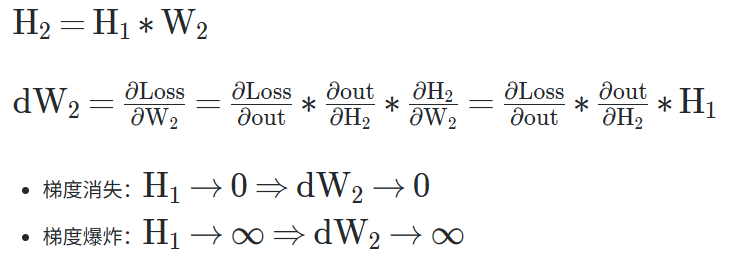  
下面我们通过代码来进行验证：

In [1]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, neural_num, layers):
        super(MLP, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(neural_num, neural_num, bias = False) for i in range(layers)])
        self.neural_num = neural_num
    
    def forward(self, x):
        for (i, linear) in enumerate(self.linears):
            x = linear(x)
        return x
    
    def initialize(self):
        for m in self.modules():
            if isinstance(m, nn.Linear): # 确保只对全连接层（nn.Linear）进行初始化
                # 标准正态分布初始化权重：nn.init.normal_ 是原地修改权重
                # mean=0, std=1 → 权重的方差=1，为方差爆炸创造条件
                nn.init.normal_(m.weight.data)

layer_nums = 100
neural_nums = 256
batch_size = 16

net = MLP(neural_nums, layer_nums)
net.initialize() #标准正态分布随机初始化权重参数
inputs = torch.randn(batch_size, neural_nums) # normal: mean=0, std=1

output = net(inputs)
print(output)

tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<MmBackward0>)


#### 2）研究nan出现的原因

两个独立随机变量乘积的方差：  
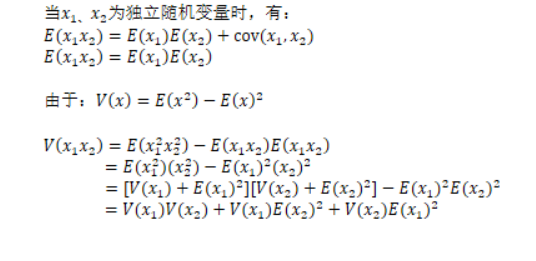  
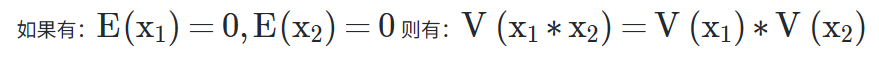  
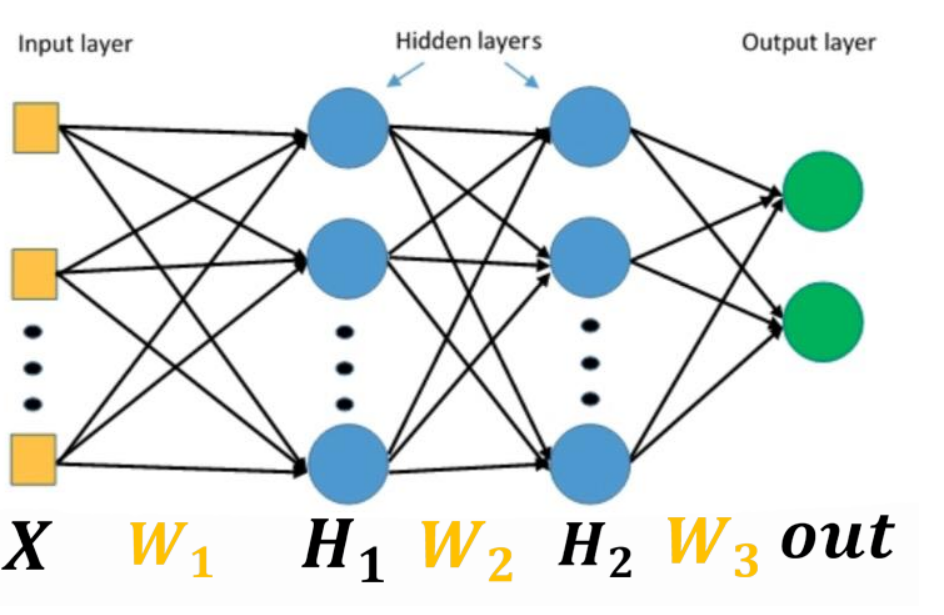  
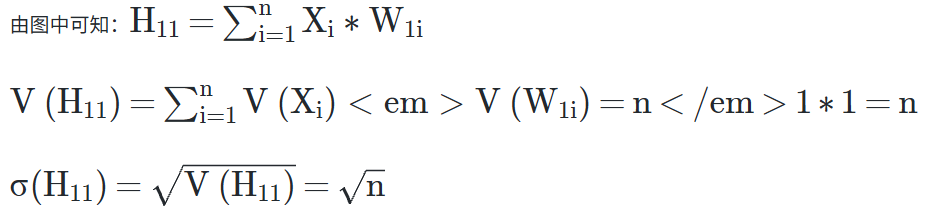

下面使用代码进行验证：

In [3]:
class MLP(nn.Module):
    def __init__(self, neural_num, layers):
        super(MLP, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(neural_num, neural_num, bias = False) for i in range(layers)])
        self.neural_num = neural_num
    
    def forward(self, x):
        for (i, linear) in enumerate(self.linears):
            x = linear(x)
            print("layer: {}, std: {}".format(i, x.std()))#输出每一层的标准差
            if torch.isnan(x.std()):
                print("output is nan in {} layers".format(i))
                break
        return x
    
    def initialize(self):
        for m in self.modules():
            if isinstance(m, nn.Linear): # 确保只对全连接层（nn.Linear）进行初始化
                # 标准正态分布初始化权重：nn.init.normal_ 是原地修改权重
                # mean=0, std=1 → 权重的方差=1，为方差爆炸创造条件
                nn.init.normal_(m.weight.data)

layer_nums = 100
neural_nums = 256
batch_size = 16

net = MLP(neural_nums, layer_nums)
net.initialize() #标准正态分布随机初始化权重参数
inputs = torch.randn(batch_size, neural_nums) # normal: mean=0, std=1

output = net(inputs)
print(output)

layer: 0, std: 16.3416748046875
layer: 1, std: 262.42987060546875
layer: 2, std: 4238.767578125
layer: 3, std: 66977.953125
layer: 4, std: 1062546.0
layer: 5, std: 16946408.0
layer: 6, std: 280740992.0
layer: 7, std: 4522119168.0
layer: 8, std: 72531025920.0
layer: 9, std: 1155200974848.0
layer: 10, std: 18109784129536.0
layer: 11, std: 293105311940608.0
layer: 12, std: 4644955054145536.0
layer: 13, std: 7.326021065061171e+16
layer: 14, std: 1.1568427753883566e+18
layer: 15, std: 1.8809739041526776e+19
layer: 16, std: 3.087543000004297e+20
layer: 17, std: 4.939345409316728e+21
layer: 18, std: 7.925820132374702e+22
layer: 19, std: 1.2672355452860608e+24
layer: 20, std: 2.069645133486394e+25
layer: 21, std: 3.351563843180348e+26
layer: 22, std: 5.313537111619302e+27
layer: 23, std: 8.277738927072654e+28
layer: 24, std: 1.3575216923111986e+30
layer: 25, std: 2.2044099829323614e+31
layer: 26, std: 3.568657334568226e+32
layer: 27, std: 5.498882612784166e+33
layer: 28, std: 9.012083653401766

为了能够让每一层的输出值限定为方差=1的范围：  
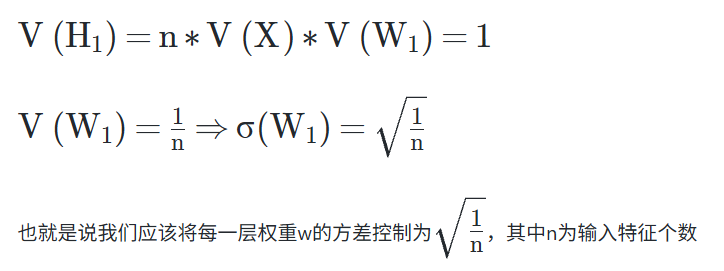  
下面使用代码进行验证：

In [5]:
import numpy as np
class MLP(nn.Module):
    def __init__(self, neural_num, layers):
        super(MLP, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(neural_num, neural_num, bias = False) for i in range(layers)])
        self.neural_num = neural_num
    
    def forward(self, x):
        for (i, linear) in enumerate(self.linears):
            x = linear(x)
            print("layer: {}, std: {}".format(i, x.std()))#输出每一层的标准差
            if torch.isnan(x.std()):
                print("output is nan in {} layers".format(i))
                break
        return x
    
    def initialize(self):
        for m in self.modules():
            if isinstance(m, nn.Linear): # 确保只对全连接层（nn.Linear）进行初始化
                nn.init.normal_(m.weight.data, std = np.sqrt(1 / self.neural_num)) # normal: mean=0, std=sqrt(1/n)

layer_nums = 100
neural_nums = 256
batch_size = 16

net = MLP(neural_nums, layer_nums)
net.initialize() #标准正态分布随机初始化权重参数
inputs = torch.randn(batch_size, neural_nums) # normal: mean=0, std=1

output = net(inputs)
print(output)

layer: 0, std: 0.976600170135498
layer: 1, std: 0.9916124939918518
layer: 2, std: 0.9734349250793457
layer: 3, std: 0.9752458930015564
layer: 4, std: 0.9872588515281677
layer: 5, std: 1.011451005935669
layer: 6, std: 1.0149965286254883
layer: 7, std: 1.0159739255905151
layer: 8, std: 0.9979555010795593
layer: 9, std: 0.9889107346534729
layer: 10, std: 0.9771913290023804
layer: 11, std: 0.9658673405647278
layer: 12, std: 0.9601242542266846
layer: 13, std: 0.968654215335846
layer: 14, std: 0.9927417635917664
layer: 15, std: 0.9968814849853516
layer: 16, std: 1.02015221118927
layer: 17, std: 1.0059701204299927
layer: 18, std: 0.9792395234107971
layer: 19, std: 0.9794639348983765
layer: 20, std: 0.9745153784751892
layer: 21, std: 0.9781762361526489
layer: 22, std: 0.9824616312980652
layer: 23, std: 0.9848150014877319
layer: 24, std: 0.9781548976898193
layer: 25, std: 0.9766798615455627
layer: 26, std: 0.9726720452308655
layer: 27, std: 0.9533377289772034
layer: 28, std: 0.9658045768737793


#### 3）考虑激活函数的作用

在网络的每一层中加入tanh激活函数，然后观察各层输出的std。

代码如下：

In [6]:
class MLP(nn.Module):
    def __init__(self, neural_num, layers):
        super(MLP, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(neural_num, neural_num, bias = False) for i in range(layers)])
        self.neural_num = neural_num
    
    def forward(self, x):
        for (i, linear) in enumerate(self.linears):
            x = linear(x)
            x = torch.tanh(x) #加入的是tanh激活函数

            print("layer: {}, std: {}".format(i, x.std()))#输出每一层的标准差
            if torch.isnan(x.std()):
                print("output is nan in {} layers".format(i))
                break
        return x
    
    def initialize(self):
        for m in self.modules():
            if isinstance(m, nn.Linear): # 确保只对全连接层（nn.Linear）进行初始化
                nn.init.normal_(m.weight.data, std = np.sqrt(1 / self.neural_num)) # normal: mean=0, std=sqrt(1/n)

layer_nums = 100
neural_nums = 256
batch_size = 16

net = MLP(neural_nums, layer_nums)
net.initialize() #标准正态分布随机初始化权重参数
inputs = torch.randn(batch_size, neural_nums) # normal: mean=0, std=1

output = net(inputs)
print(output)

layer: 0, std: 0.6252732872962952
layer: 1, std: 0.4808928072452545
layer: 2, std: 0.40479958057403564
layer: 3, std: 0.3500986099243164
layer: 4, std: 0.3086566925048828
layer: 5, std: 0.28389811515808105
layer: 6, std: 0.26065534353256226
layer: 7, std: 0.24199938774108887
layer: 8, std: 0.2304949313402176
layer: 9, std: 0.21867595613002777
layer: 10, std: 0.20783206820487976
layer: 11, std: 0.19744274020195007
layer: 12, std: 0.19155004620552063
layer: 13, std: 0.1886834353208542
layer: 14, std: 0.18394094705581665
layer: 15, std: 0.17521008849143982
layer: 16, std: 0.16825488209724426
layer: 17, std: 0.1622229367494583
layer: 18, std: 0.15596136450767517
layer: 19, std: 0.15023769438266754
layer: 20, std: 0.14805331826210022
layer: 21, std: 0.1448793113231659
layer: 22, std: 0.14334166049957275
layer: 23, std: 0.1419786959886551
layer: 24, std: 0.14188723266124725
layer: 25, std: 0.1375141441822052
layer: 26, std: 0.13573893904685974
layer: 27, std: 0.13208936154842377
layer: 28, s

### 8.2 方差一致性初始化  
方差一致性：保持数据尺度维持在恰当范围，通常方差为1  
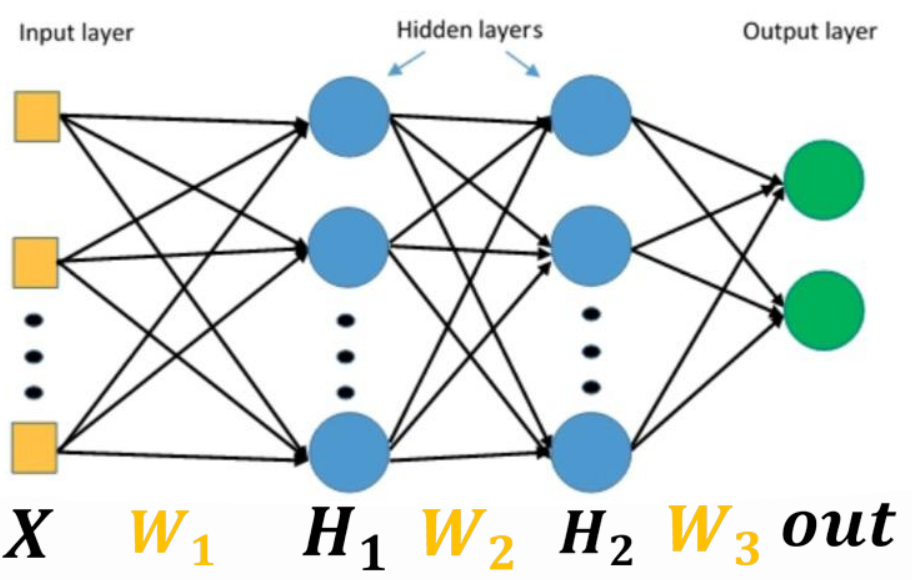  
图中可以看出，权重W跟前后两层的神经元个数都相关！！！

#### 1）Xavier初始化
- 考虑激活函数：饱和函数，如Sigmoid，Tanh 考虑前后两层输出方差均为1：  
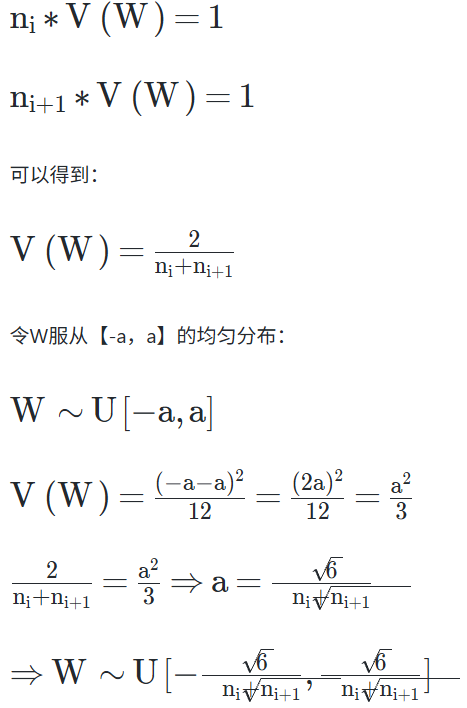

In [9]:
class MLP(nn.Module):
    def __init__(self, neural_num, layers):
        super(MLP, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(neural_num, neural_num, bias = False) for i in range(layers)])
        self.neural_num = neural_num
    
    def forward(self, x):
        for (i, linear) in enumerate(self.linears):
            x = linear(x)
            x = torch.tanh(x)

            print("layer: {}, std: {}".format(i, x.std()))#输出每一层的标准差
        return x
    
    def initialize(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):

                tanh_gain = nn.init.calculate_gain('tanh') #考虑激活函数的方差变化尺度
                # a = np.sqrt(6 / (self.neural_num + self.neural_num))
                # a *= tanh_gain
                # nn.init.uniform_(m.weight.data, -a, a) #按公式实现
                nn.init.xavier_uniform_(m.weight.data, gain = tanh_gain) #pytorch实现的xavier_uniform_

layer_nums = 100
neural_nums = 256
batch_size = 16

net = MLP(neural_nums, layer_nums)
net.initialize() #标准正态分布随机初始化权重参数
inputs = torch.randn(batch_size, neural_nums) # normal: mean=0, std=1

output = net(inputs)
print(output)

layer: 0, std: 0.7509721517562866
layer: 1, std: 0.6870074272155762
layer: 2, std: 0.6658499836921692
layer: 3, std: 0.6592919230461121
layer: 4, std: 0.6613476872444153
layer: 5, std: 0.6572892069816589
layer: 6, std: 0.650231122970581
layer: 7, std: 0.6485334634780884
layer: 8, std: 0.6526217460632324
layer: 9, std: 0.6554116606712341
layer: 10, std: 0.6543819308280945
layer: 11, std: 0.6493409872055054
layer: 12, std: 0.6503667831420898
layer: 13, std: 0.6535257697105408
layer: 14, std: 0.6550943851470947
layer: 15, std: 0.6490422487258911
layer: 16, std: 0.647408664226532
layer: 17, std: 0.6482012867927551
layer: 18, std: 0.6464858651161194
layer: 19, std: 0.6514716744422913
layer: 20, std: 0.6476564407348633
layer: 21, std: 0.6443343758583069
layer: 22, std: 0.6487191915512085
layer: 23, std: 0.6458269953727722
layer: 24, std: 0.6461820602416992
layer: 25, std: 0.6470020413398743
layer: 26, std: 0.6506606936454773
layer: 27, std: 0.6451871991157532
layer: 28, std: 0.64771544933319

#### 2）Kaiming初始化
- 考虑激活函数：ReLU及其变种  

**修改激活函数为relu代码演示：**

In [10]:
class MLP(nn.Module):
    def __init__(self, neural_num, layers):
        super(MLP, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(neural_num, neural_num, bias = False) for i in range(layers)])
        self.neural_num = neural_num
    
    def forward(self, x):
        for (i, linear) in enumerate(self.linears):
            x = linear(x)
            x = torch.relu(x)

            print("layer: {}, std: {}".format(i, x.std()))#输出每一层的标准差
        return x
    
    def initialize(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):

                relu_gain = nn.init.calculate_gain('relu') #考虑激活函数的方差变化尺度
                nn.init.xavier_uniform_(m.weight.data, gain = relu_gain) #pytorch实现的xavier_uniform_

layer_nums = 100
neural_nums = 256
batch_size = 16

net = MLP(neural_nums, layer_nums)
net.initialize() #标准正态分布随机初始化权重参数
inputs = torch.randn(batch_size, neural_nums) # normal: mean=0, std=1

output = net(inputs)
print(output)

layer: 0, std: 0.8206636905670166
layer: 1, std: 0.8285881280899048
layer: 2, std: 0.8421658873558044
layer: 3, std: 0.8429498076438904
layer: 4, std: 0.786745011806488
layer: 5, std: 0.7854539155960083
layer: 6, std: 0.7649006247520447
layer: 7, std: 0.714621365070343
layer: 8, std: 0.7054540514945984
layer: 9, std: 0.6838119626045227
layer: 10, std: 0.6450881958007812
layer: 11, std: 0.6722583174705505
layer: 12, std: 0.6778703927993774
layer: 13, std: 0.6829086542129517
layer: 14, std: 0.7196959853172302
layer: 15, std: 0.7168727517127991
layer: 16, std: 0.7157741189002991
layer: 17, std: 0.7050732970237732
layer: 18, std: 0.7236633896827698
layer: 19, std: 0.7109805345535278
layer: 20, std: 0.6503582000732422
layer: 21, std: 0.639137864112854
layer: 22, std: 0.644910991191864
layer: 23, std: 0.617931604385376
layer: 24, std: 0.5557336807250977
layer: 25, std: 0.5279265642166138
layer: 26, std: 0.47247248888015747
layer: 27, std: 0.4020465612411499
layer: 28, std: 0.3713993728160858

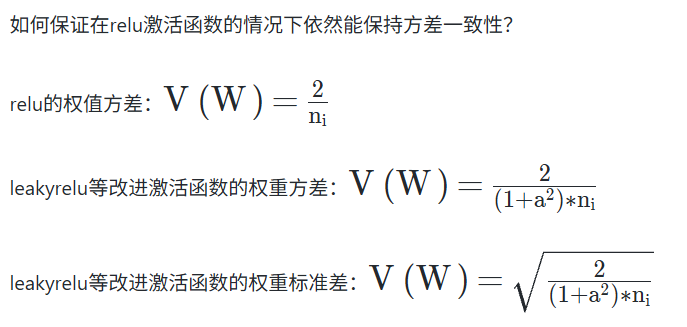

In [20]:
class MLP(nn.Module):
    def __init__(self, neural_num, layers):
        super(MLP, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(neural_num, neural_num, bias = False) for i in range(layers)])
        self.neural_num = neural_num
    
    def forward(self, x):
        for (i, linear) in enumerate(self.linears):
            x = linear(x)
            x = torch.relu(x)
            print("layer: {}, std: {}".format(i, x.std()))#输出每一层的标准差
        return x
    
    def initialize(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                #nn.init.normal_(m.weight.data, std=np.sqrt(2 / self.neural_num))
                nn.init.kaiming_normal_(m.weight.data) #pytorch实现的kaiming_normal_

layer_nums = 100
neural_nums = 256
batch_size = 16

net = MLP(neural_nums, layer_nums)
net.initialize() #标准正态分布随机初始化权重参数
inputs = torch.randn(batch_size, neural_nums) # normal: mean=0, std=1

output = net(inputs)
print(output)

layer: 0, std: 0.8209065198898315
layer: 1, std: 0.8285155296325684
layer: 2, std: 0.7947680950164795
layer: 3, std: 0.7730391025543213
layer: 4, std: 0.7569881081581116
layer: 5, std: 0.7831197381019592
layer: 6, std: 0.7490087747573853
layer: 7, std: 0.72966068983078
layer: 8, std: 0.684255838394165
layer: 9, std: 0.6571334600448608
layer: 10, std: 0.6149840950965881
layer: 11, std: 0.5658061504364014
layer: 12, std: 0.5711469054222107
layer: 13, std: 0.6193572282791138
layer: 14, std: 0.6198054552078247
layer: 15, std: 0.6322653293609619
layer: 16, std: 0.5628528594970703
layer: 17, std: 0.5789980888366699
layer: 18, std: 0.5547294616699219
layer: 19, std: 0.5041179060935974
layer: 20, std: 0.5300887823104858
layer: 21, std: 0.5390113592147827
layer: 22, std: 0.5534639954566956
layer: 23, std: 0.6055497527122498
layer: 24, std: 0.5871854424476624
layer: 25, std: 0.5553690791130066
layer: 26, std: 0.5308806896209717
layer: 27, std: 0.49815091490745544
layer: 28, std: 0.54161554574966

#### 3）nn.init.calculate_gain

nn.init.calculate_gain(nonlinearity, param=None)

- 主要功能：计算激活函数的方差变化尺度
- 主要参数
    - nonlinearity: 激活函数名称
    - param: 激活函数的参数，如Leaky ReLU的negative_slop

In [22]:
x = torch.randn(10000)
out = torch.tanh(x)

gain = x.std() / out.std() #手动计算
print(f'gain: {gain}')

tanh_gain = nn.init.calculate_gain('tanh')
print(f'tanh_gain in PyTorch: {tanh_gain}')

gain: 1.5925925970077515
tanh_gain in PyTorch: 1.6666666666666667


### 7.3 十种初始化方法及使用
#### 1）十种初始化方法

PyTorch 在 torch.nn.init 中供了常用的初始化方法函数
- Xavie r均匀分布：torch.nn.init.xavier_uniform_(tensor, gain=1)
- Xavie r正态分布：torch.nn.init.xavier_normal_(tensor, gain=1)
- Kaiming均匀分布：torch.nn.init.kaiming_uniform_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')
- Kaiming正态分布：torch.nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')
- 均匀分布：torch.nn.init.uniform_(tensor, a=0, b=1)
- 正态分布：torch.nn.init.normal_(tensor, mean=0, std=1)
- 常数分布：torch.nn.init.constant_(tensor, val)
- 正交矩阵初始化：torch.nn.init.orthogonal_(tensor, gain=1)
- 单位矩阵初始化：torch.nn.init.eye_(tensor)
- 稀疏矩阵初始化：torch.nn.init.sparse_(tensor, sparsity, std=0.01)

#### 2）权重初始化实战手写数字识别
##### 2.1 构建数据集

In [24]:
import torchvision
n_epochs = 3
batch_size_train = 64
batch_size_test = 64
learning_rate = 0.01
log_interval = 10
random_seed = 1
torch.manual_seed(random_seed)
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('Dataset/', train = True, download = True,
                               transform = torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                       (0.1307,), (0.3081,))
                               ])),
    batch_size = batch_size_train, shuffle = True
)
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('Dataset/', train = False, download = True,
                               transform = torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                       (0.1307,), (0.3081,))
                               ])),
    batch_size = batch_size_test, shuffle = True
)

##### 2.2 构建网络

In [34]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320) # -1自动计算批次n，320是chw的总数，合并成一个维度
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)
    def initialize_normal(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight.data)
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight.data)
    def initialize_kaiming(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight.data)
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight.data)

##### 2.3初始化网络和优化器

In [26]:
network = Net()
loss_func = torch.nn.NLLLoss()
optimizer = optim.Adam(network.parameters(), lr = learning_rate)

##### 2.4 正态分布初始化训练

In [27]:
for batch_idx, (data, target) in enumerate(train_loader):
    print(f"批次索引 batch_idx: {batch_idx}")
    print(f"data 形状: {data.shape}")  # 输出 torch.Size([64, 1, 28, 28])
    print(f"单张图片维度（CHW）: {data[0].shape}")  # 输出 torch.Size([1, 28, 28])
    print(f"target 形状: {target.shape}")  # 输出 torch.Size([64])
    print(f"前5个标签值: {target[:5]}")  # 输出类似 tensor([3, 7, 0, 2, 9])
    break  # 只看第一批，避免遍历全部数据

批次索引 batch_idx: 0
data 形状: torch.Size([64, 1, 28, 28])
单张图片维度（CHW）: torch.Size([1, 28, 28])
target 形状: torch.Size([64])
前5个标签值: tensor([1, 9, 7, 3, 6])


In [30]:
network.initialize_normal()
network.train()
for epoch in range(n_epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0 and batch_idx != 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)} / {len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

Train Epoch: 0 [640 / 60000 (1%)]	Loss: 858.324341
Train Epoch: 0 [1280 / 60000 (2%)]	Loss: 163.902618
Train Epoch: 0 [1920 / 60000 (3%)]	Loss: 42.784187
Train Epoch: 0 [2560 / 60000 (4%)]	Loss: 9.323139
Train Epoch: 0 [3200 / 60000 (5%)]	Loss: 2.857935
Train Epoch: 0 [3840 / 60000 (6%)]	Loss: 3.221090
Train Epoch: 0 [4480 / 60000 (7%)]	Loss: 2.499151
Train Epoch: 0 [5120 / 60000 (9%)]	Loss: 3.052770
Train Epoch: 0 [5760 / 60000 (10%)]	Loss: 2.302666
Train Epoch: 0 [6400 / 60000 (11%)]	Loss: 2.298075
Train Epoch: 0 [7040 / 60000 (12%)]	Loss: 2.297879
Train Epoch: 0 [7680 / 60000 (13%)]	Loss: 2.294359
Train Epoch: 0 [8320 / 60000 (14%)]	Loss: 2.292712
Train Epoch: 0 [8960 / 60000 (15%)]	Loss: 2.384061
Train Epoch: 0 [9600 / 60000 (16%)]	Loss: 2.295550
Train Epoch: 0 [10240 / 60000 (17%)]	Loss: 2.314926
Train Epoch: 0 [10880 / 60000 (18%)]	Loss: 2.299801
Train Epoch: 0 [11520 / 60000 (19%)]	Loss: 2.300223
Train Epoch: 0 [12160 / 60000 (20%)]	Loss: 2.281064
Train Epoch: 0 [12800 / 60000 (

In [35]:
network.initialize_kaiming() # 使用kaiming方法初始化
network.train()
for epoch in range(n_epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = loss_func(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0 and batch_idx != 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)} / {len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_21904\2757165569.py:32: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  nn.init.kaiming_normal(m.weight.data)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_21904\2757165569.py:30: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  nn.init.kaiming_normal(m.weight.data)


Train Epoch: 0 [640 / 60000 (1%)]	Loss: 2.279909
Train Epoch: 0 [1280 / 60000 (2%)]	Loss: 2.286865
Train Epoch: 0 [1920 / 60000 (3%)]	Loss: 2.287386
Train Epoch: 0 [2560 / 60000 (4%)]	Loss: 2.223092
Train Epoch: 0 [3200 / 60000 (5%)]	Loss: 2.130372
Train Epoch: 0 [3840 / 60000 (6%)]	Loss: 2.159734
Train Epoch: 0 [4480 / 60000 (7%)]	Loss: 2.123408
Train Epoch: 0 [5120 / 60000 (9%)]	Loss: 2.116073
Train Epoch: 0 [5760 / 60000 (10%)]	Loss: 2.075947
Train Epoch: 0 [6400 / 60000 (11%)]	Loss: 1.809599
Train Epoch: 0 [7040 / 60000 (12%)]	Loss: 2.020582
Train Epoch: 0 [7680 / 60000 (13%)]	Loss: 2.004094
Train Epoch: 0 [8320 / 60000 (14%)]	Loss: 2.116397
Train Epoch: 0 [8960 / 60000 (15%)]	Loss: 1.908151
Train Epoch: 0 [9600 / 60000 (16%)]	Loss: 1.747355
Train Epoch: 0 [10240 / 60000 (17%)]	Loss: 1.834996
Train Epoch: 0 [10880 / 60000 (18%)]	Loss: 1.722677
Train Epoch: 0 [11520 / 60000 (19%)]	Loss: 1.547939
Train Epoch: 0 [12160 / 60000 (20%)]	Loss: 1.720567
Train Epoch: 0 [12800 / 60000 (21%)]